# CFR Convergence & Exploitability Analysis

This notebook trains CFR incrementally and measures **exploitability** at each checkpoint to verify convergence toward Nash equilibrium.

**Exploitability** = (best_response_value_p0 + best_response_value_p1) / 2

At Nash equilibrium, exploitability = 0.

In [13]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
from itertools import permutations
from src.algorithms.cfr import CFR
from src.training.kuhn_poker import KuhnPokerRules
from src.training.leduc_poker import LeducPokerRules
from src.training.limit_poker import LimitPokerRules

## Exploitability Computation

To compute exploitability we find the **best response** for each player against the opponent's average strategy, then average the gains.

In [14]:
def _get_all_deals(game):
    """Enumerate all possible card deals for the game."""
    if isinstance(game, KuhnPokerRules):
        return list(permutations([0, 1, 2], 2))
    elif isinstance(game, LeducPokerRules):
        return list(permutations([0, 1, 2, 3, 4, 5], 3))
    raise ValueError("Unknown game type — use compute_exploitability_sampled for large games")


def _node_info(game, cards, history):
    """Extract common node information."""
    player = game.get_acting_player(history)
    player_card = cards[player]
    flop = cards[2] if len(cards) > 2 else None
    return player, player_card, (flop, None, None)


def _traverse_br(game, opp_strategy, br_pure, br_player, cards, history, opp_reach, cf_values):
    player, player_card, com_cards = _node_info(game, cards, history)

    if game.is_terminal(history):
        sign = 1 if br_player == 0 else -1
        return opp_reach * sign * game.get_payoff(cards[:2], history, com_cards)

    actions = game.get_legal_actions(history)
    info_set_key = game.get_info_set_string(player_card, history, com_cards)

    if player == br_player:
        if info_set_key not in cf_values:
            cf_values[info_set_key] = [0.0] * len(actions)

        action_vals = []
        for i, action in enumerate(actions):
            val = _traverse_br(game, opp_strategy, br_pure, br_player, cards,
                               history + action, opp_reach, cf_values)
            cf_values[info_set_key][i] += val
            action_vals.append(val)

        if info_set_key in br_pure:
            return action_vals[br_pure[info_set_key]]
        return max(action_vals)
    else:
        strat = opp_strategy.get(info_set_key, [1.0 / len(actions)] * len(actions))
        ev = 0.0
        for i, action in enumerate(actions):
            ev += _traverse_br(game, opp_strategy, br_pure, br_player, cards,
                               history + action, opp_reach * strat[i], cf_values)
        return ev


def _eval_br(game, opp_strategy, br_pure, br_player, cards, history, opp_reach):
    player, player_card, com_cards = _node_info(game, cards, history)

    if game.is_terminal(history):
        sign = 1 if br_player == 0 else -1
        return opp_reach * sign * game.get_payoff(cards[:2], history, com_cards)

    actions = game.get_legal_actions(history)
    info_set_key = game.get_info_set_string(player_card, history, com_cards)

    if player == br_player:
        chosen = br_pure.get(info_set_key, 0)
        return _eval_br(game, opp_strategy, br_pure, br_player, cards,
                        history + actions[chosen], opp_reach)
    else:
        strat = opp_strategy.get(info_set_key, [1.0 / len(actions)] * len(actions))
        ev = 0.0
        for i, action in enumerate(actions):
            ev += _eval_br(game, opp_strategy, br_pure, br_player, cards,
                           history + action, opp_reach * strat[i])
        return ev


def compute_exploitability(game, strategy):
    deals = _get_all_deals(game)

    total_expl = 0.0
    for br_player in [0, 1]:
        br_pure = {}

        for _ in range(20):
            cf_values = {}
            for deal in deals:
                _traverse_br(game, strategy, br_pure, br_player, deal, "", 1.0, cf_values)

            new_br_pure = {}
            for key, action_vals in cf_values.items():
                new_br_pure[key] = max(range(len(action_vals)),
                                       key=lambda i, av=action_vals: av[i])

            if new_br_pure == br_pure:
                break
            br_pure = new_br_pure

        br_value = sum(
            _eval_br(game, strategy, br_pure, br_player, deal, "", 1.0)
            for deal in deals
        ) / len(deals)
        total_expl += br_value

    return total_expl / 2.0


def compute_exploitability_sampled(game, strategy, num_samples=200, br_iters=10):
    """MC estimate of exploitability for large games (e.g. limit poker)."""
    total_expl = 0.0
    for br_player in [0, 1]:
        br_pure = {}

        for _ in range(br_iters):
            cf_values = {}
            for _ in range(num_samples):
                deal = game.deal_cards()
                _traverse_br(game, strategy, br_pure, br_player, deal, "", 1.0, cf_values)

            new_br_pure = {k: max(range(len(v)), key=lambda i, av=v: av[i])
                           for k, v in cf_values.items()}
            if new_br_pure == br_pure:
                break
            br_pure = new_br_pure

        br_value = sum(
            _eval_br(game, strategy, br_pure, br_player, game.deal_cards(), "", 1.0)
            for _ in range(num_samples)
        ) / num_samples
        total_expl += br_value

    return total_expl / 2.0

## Train with Exploitability Checkpoints

Train incrementally: run N iterations at a time, measure exploitability, repeat.

In [15]:
def train_with_checkpoints(game, total_iterations, num_checkpoints=50):
    """
    Train CFR and measure exploitability at evenly-spaced checkpoints.

    Returns:
        iterations_list: list of iteration counts at each checkpoint
        exploitability_list: list of exploitability values
        cfr: the trained CFR object
    """
    cfr = CFR(game)
    checkpoint_interval = max(1, total_iterations // num_checkpoints)

    iterations_list = []
    exploitability_list = []
    current_iter = 0

    for i in range(num_checkpoints):
        cfr.train(checkpoint_interval)
        current_iter += checkpoint_interval

        strategy = cfr.get_strategy()
        expl = compute_exploitability(game, strategy)

        iterations_list.append(current_iter)
        exploitability_list.append(expl)

        if (i + 1) % 10 == 0:
            print(f"  Iteration {current_iter:>8d}  |  Exploitability: {expl:.6f}")

    return iterations_list, exploitability_list, cfr

## Kuhn Poker Convergence

In [16]:
print("Training Kuhn Poker CFR...")
kuhn_game = KuhnPokerRules()
kuhn_iters, kuhn_expl, kuhn_cfr = train_with_checkpoints(kuhn_game, total_iterations=100_000, num_checkpoints=50)
print(f"\nFinal exploitability: {kuhn_expl[-1]:.8f}")

Training Kuhn Poker CFR...
  Iteration    20000  |  Exploitability: 0.005496
  Iteration    40000  |  Exploitability: 0.002038
  Iteration    60000  |  Exploitability: 0.002601
  Iteration    80000  |  Exploitability: 0.002193
  Iteration   100000  |  Exploitability: 0.001732

Final exploitability: 0.00173208


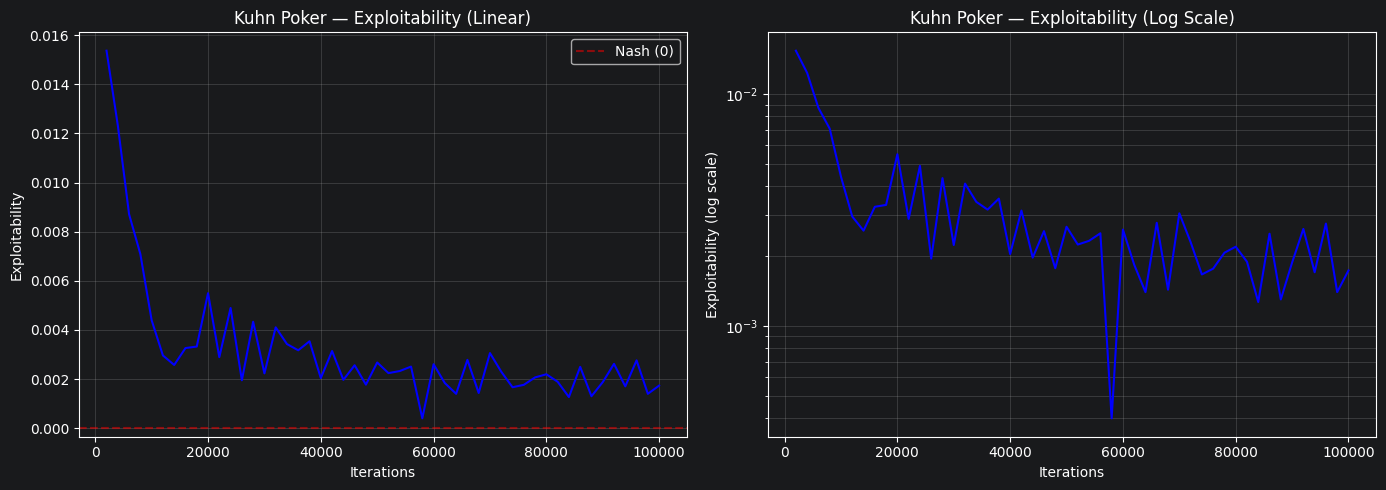

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(kuhn_iters, kuhn_expl, 'b-', linewidth=1.5)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Nash (0)')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Exploitability')
axes[0].set_title('Kuhn Poker — Exploitability (Linear)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].plot(kuhn_iters, kuhn_expl, 'b-', linewidth=1.5)
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Exploitability (log scale)')
axes[1].set_title('Kuhn Poker — Exploitability (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Kuhn Poker — Final Strategy vs Known Nash Equilibrium

In [18]:
kuhn_strategy = kuhn_cfr.get_strategy()

# Known Nash equilibrium ranges for Kuhn Poker
# P0 opening: J bets ~1/3, Q always passes, K always bets (with some mixing)
nash_reference = {
    'J:':   [2/3, 1/3],     # P0 with J: pass 2/3, bet 1/3
    'Q:':   [1.0, 0.0],     # P0 with Q: always pass
    'K:':   [0.0, 1.0],     # P0 with K: always bet (simplified)
    'J:P':  [2/3, 1/3],     # P1 facing check with J: pass 2/3, bet 1/3
    'Q:P':  [1.0, 0.0],     # P1 facing check with Q: always pass
    'K:P':  [0.0, 1.0],     # P1 facing check with K: always bet
    'J:B':  [1.0, 0.0],     # P1 facing bet with J: always fold
    'Q:B':  [2/3, 1/3],     # P1 facing bet with Q: fold 2/3, call 1/3
    'K:B':  [0.0, 1.0],     # P1 facing bet with K: always call
    'J:PB': [1.0, 0.0],     # P0 facing check-bet with J: always fold
    'Q:PB': [2/3, 1/3],     # P0 facing check-bet with Q: fold 2/3, call 1/3
    'K:PB': [0.0, 1.0],     # P0 facing check-bet with K: always call
}

print(f"{'Info Set':<10} {'Action 0 (P/F)':>14} {'Action 1 (B/C)':>14} {'Nash P':>10} {'Nash B':>10}")
print('-' * 62)
for key in sorted(kuhn_strategy.keys()):
    s = kuhn_strategy[key]
    nash = nash_reference.get(key, [None, None])
    nash_str = [f"{v:.3f}" if v is not None else "?" for v in nash]
    print(f"{key:<10} {s[0]:>14.3f} {s[1]:>14.3f} {nash_str[0]:>10} {nash_str[1]:>10}")

Info Set   Action 0 (P/F) Action 1 (B/C)     Nash P     Nash B
--------------------------------------------------------------
J:                  0.700          0.300      0.667      0.333
J:B                 1.000          0.000      1.000      0.000
J:P                 0.672          0.328      0.667      0.333
J:PB                1.000          0.000      1.000      0.000
K:                  0.098          0.902      0.000      1.000
K:B                 0.000          1.000      0.000      1.000
K:P                 0.000          1.000      0.000      1.000
K:PB                0.000          1.000      0.000      1.000
Q:                  1.000          0.000      1.000      0.000
Q:B                 0.666          0.334      0.667      0.333
Q:P                 1.000          0.000      1.000      0.000
Q:PB                0.357          0.643      0.667      0.333


## Leduc Poker Convergence

In [19]:
print("Training Leduc Poker CFR (this takes longer)...")
leduc_game = LeducPokerRules()
leduc_iters, leduc_expl, leduc_cfr = train_with_checkpoints(leduc_game, total_iterations=100_000, num_checkpoints=50)
print(f"\nFinal exploitability: {leduc_expl[-1]:.8f}")

Training Leduc Poker CFR (this takes longer)...
  Iteration    20000  |  Exploitability: 0.065598
  Iteration    40000  |  Exploitability: 0.038783
  Iteration    60000  |  Exploitability: 0.035336
  Iteration    80000  |  Exploitability: 0.030950
  Iteration   100000  |  Exploitability: 0.026488

Final exploitability: 0.02648846


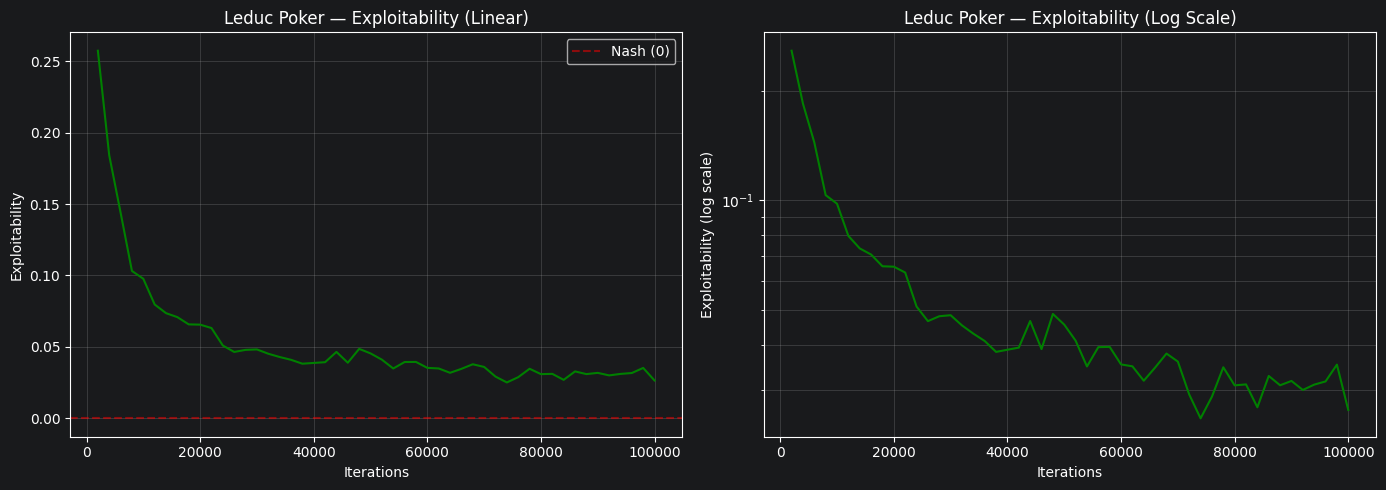

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(leduc_iters, leduc_expl, 'g-', linewidth=1.5)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Nash (0)')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Exploitability')
axes[0].set_title('Leduc Poker — Exploitability (Linear)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(leduc_iters, leduc_expl, 'g-', linewidth=1.5)
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Exploitability (log scale)')
axes[1].set_title('Leduc Poker — Exploitability (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Side-by-Side Comparison

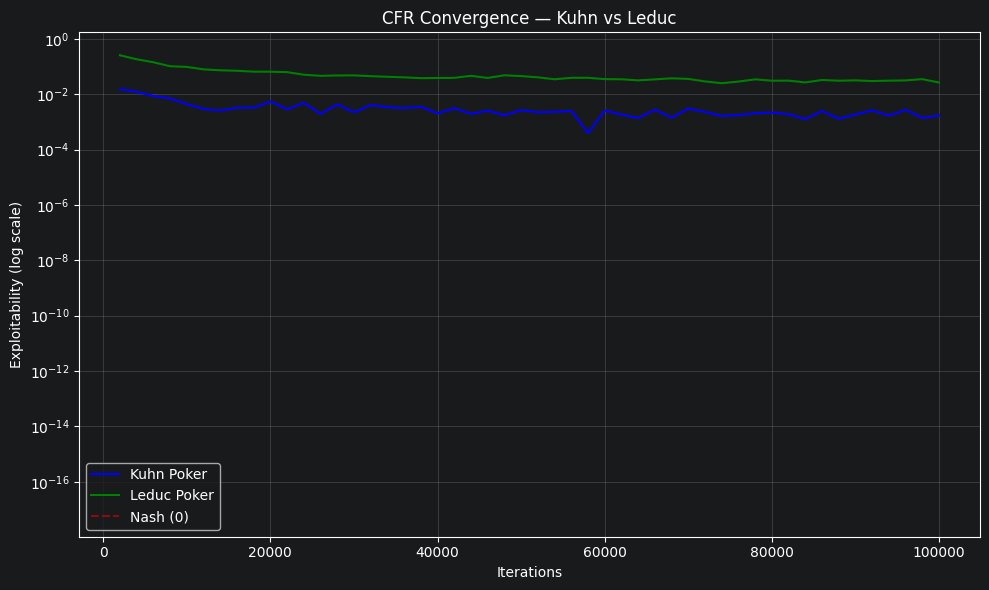

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(kuhn_iters, kuhn_expl, 'b-', linewidth=1.5, label='Kuhn Poker')
ax.plot(leduc_iters, leduc_expl, 'g-', linewidth=1.5, label='Leduc Poker')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Nash (0)')

ax.set_xlabel('Iterations')
ax.set_ylabel('Exploitability (log scale)')
ax.set_title('CFR Convergence — Kuhn vs Leduc')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Note: Three-way comparison including Limit Poker is at the end of the notebook

## Convergence Rate Analysis

Vanilla CFR converges at O(1/√T). Let's verify this by fitting the log-log slope.

In [22]:
for name, iters, expl in [("Kuhn", kuhn_iters, kuhn_expl), ("Leduc", leduc_iters, leduc_expl)]:
    # Use second half of data for fitting (past initial transient)
    half = len(iters) // 2
    log_iters = np.log(iters[half:])
    log_expl = np.log(expl[half:])

    coeffs = np.polyfit(log_iters, log_expl, 1)
    slope = coeffs[0]
    print(f"{name} Poker — log-log slope: {slope:.3f}  (expected ~-0.5 for vanilla CFR)")

Kuhn Poker — log-log slope: 0.084  (expected ~-0.5 for vanilla CFR)
Leduc Poker — log-log slope: -0.392  (expected ~-0.5 for vanilla CFR)


## Leduc Poker — Sample Strategies

In [23]:
leduc_strategy = leduc_cfr.get_strategy()

# Show round 1 opening strategies
print("Round 1 — Opening strategies (history='')")
print(f"{'Info Set':<12} {'Pass':>8} {'Bet':>8}")
print('-' * 30)
for card_name in ['J', 'Q', 'K']:
    key = f"{card_name}:"
    if key in leduc_strategy:
        s = leduc_strategy[key]
        print(f"{key:<12} {s[0]:>8.3f} {s[1]:>8.3f}")

print("\nRound 2 — Opening strategies after check-check (history='PP//')")
print(f"{'Info Set':<12} {'Pass':>8} {'Bet':>8}")
print('-' * 30)
for hole in ['J', 'Q', 'K']:
    for board in ['J', 'Q', 'K']:
        key = f"{hole}|{board}:PP//"
        if key in leduc_strategy:
            s = leduc_strategy[key]
            print(f"{key:<12} {s[0]:>8.3f} {s[1]:>8.3f}")

Round 1 — Opening strategies (history='')
Info Set         Pass      Bet
------------------------------
J:              0.916    0.084
Q:              0.277    0.723
K:              0.294    0.706

Round 2 — Opening strategies after check-check (history='PP//')
Info Set         Pass      Bet
------------------------------
J|J:PP//        1.000    0.000
J|Q:PP//        0.966    0.034
J|K:PP//        0.879    0.121
Q|J:PP//        1.000    0.000
Q|Q:PP//        0.902    0.098
Q|K:PP//        0.736    0.264
K|J:PP//        0.999    0.001
K|Q:PP//        0.999    0.001
K|K:PP//        0.009    0.991


## Limit Poker Convergence

Full 52-card, 4-street heads-up limit hold'em with bucket abstraction (8 equity buckets per street).

Exploitability is estimated via MC sampling since the game tree is too large for full enumeration. Equity estimates are cached per unique (hole cards, board) via `lru_cache` so each combo is computed only once.

**Info set format:** `b{bucket}:{history}` (e.g. `b5:BRC//PP//B`)

In [24]:
def train_with_checkpoints_limit(game, total_iterations, num_checkpoints=20, num_samples=100):
    """Train CFR for limit poker, estimate exploitability via MC sampling at checkpoints."""
    cfr = CFR(game)
    checkpoint_interval = max(1, total_iterations // num_checkpoints)

    iterations_list = []
    exploitability_list = []
    current_iter = 0

    for i in range(num_checkpoints):
        cfr.train(checkpoint_interval)
        current_iter += checkpoint_interval

        strategy = cfr.get_strategy()
        expl = compute_exploitability_sampled(game, strategy, num_samples=num_samples)

        iterations_list.append(current_iter)
        exploitability_list.append(expl)
        print(f"  Iteration {current_iter:>6d}  |  Exploitability (MC): {expl:.4f}  |  Info sets: {len(cfr.info_sets)}")

    return iterations_list, exploitability_list, cfr


print("Training Limit Poker CFR...")
limit_game = LimitPokerRules()
limit_iters, limit_expl, limit_cfr = train_with_checkpoints_limit(
    limit_game, total_iterations=5_000, num_checkpoints=20, num_samples=100
)
print(f"\nFinal exploitability (MC estimate): {limit_expl[-1]:.6f}")
print(f"Unique info sets: {len(limit_cfr.info_sets)}")

Training Limit Poker CFR...
  Iteration    250  |  Exploitability (MC): 1.0833  |  Info sets: 72095
  Iteration    500  |  Exploitability (MC): 2.5948  |  Info sets: 72095
  Iteration    750  |  Exploitability (MC): 2.0330  |  Info sets: 72095
  Iteration   1000  |  Exploitability (MC): 2.3716  |  Info sets: 72095
  Iteration   1250  |  Exploitability (MC): 2.0319  |  Info sets: 72095
  Iteration   1500  |  Exploitability (MC): 1.4685  |  Info sets: 72095
  Iteration   1750  |  Exploitability (MC): 1.1159  |  Info sets: 72095
  Iteration   2000  |  Exploitability (MC): 0.6767  |  Info sets: 72095
  Iteration   2250  |  Exploitability (MC): -0.8953  |  Info sets: 72095
  Iteration   2500  |  Exploitability (MC): 0.4951  |  Info sets: 72095
  Iteration   2750  |  Exploitability (MC): -1.8068  |  Info sets: 72095
  Iteration   3000  |  Exploitability (MC): -1.1082  |  Info sets: 72095
  Iteration   3250  |  Exploitability (MC): -0.1834  |  Info sets: 72095
  Iteration   3500  |  Exploitab

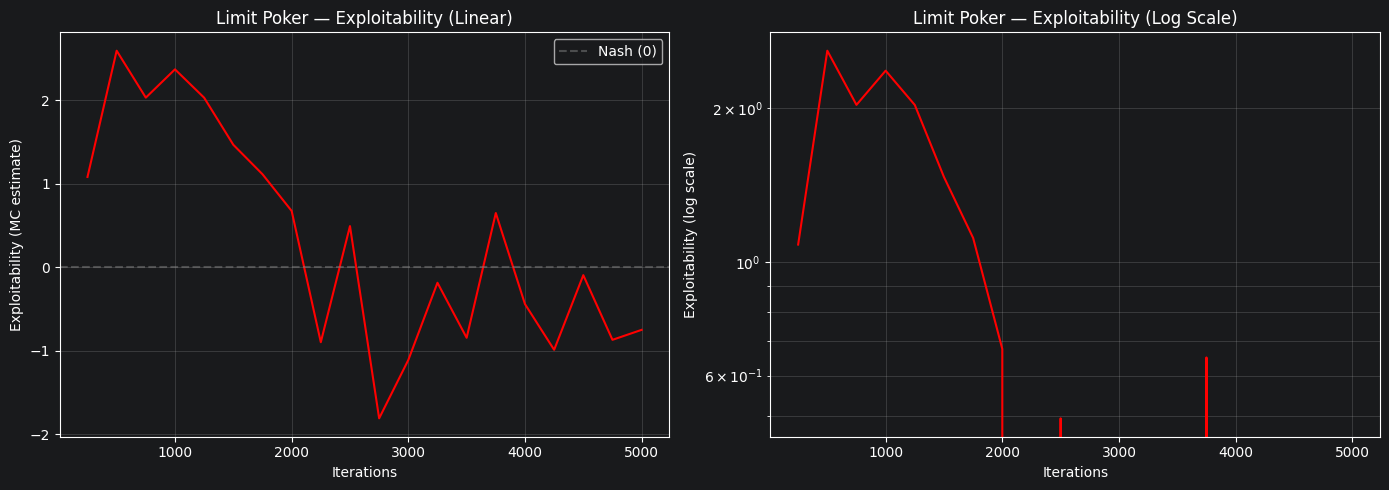

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(limit_iters, limit_expl, 'r-', linewidth=1.5)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Nash (0)')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Exploitability (MC estimate)')
axes[0].set_title('Limit Poker — Exploitability (Linear)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(limit_iters, limit_expl, 'r-', linewidth=1.5)
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Exploitability (log scale)')
axes[1].set_title('Limit Poker — Exploitability (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Limit Poker — Sample Strategies

In [26]:
limit_strategy = limit_cfr.get_strategy()

# Show preflop opening strategies per bucket
preflop_open = {k: v for k, v in limit_strategy.items() if ':' in k and k.split(':')[1] == ''}
print(f"Preflop opening — {len(preflop_open)} bucket info sets")
print(f"{'Info Set':<12} {'Pass':>8} {'Bet':>8}")
print('-' * 30)
for key in sorted(preflop_open.keys()):
    s = preflop_open[key]
    print(f"{key:<12} {s[0]:>8.3f} {s[1]:>8.3f}")

# Show a sample of flop strategies (after preflop check-check)
print(f"\nFlop opening after preflop PP (history='PP//')")
flop_open = {k: v for k, v in limit_strategy.items() if k.endswith(':PP//')}
print(f"{'Info Set':<16} {'Pass':>8} {'Bet':>8}")
print('-' * 34)
for key in sorted(flop_open.keys()):
    s = flop_open[key]
    print(f"{key:<16} {s[0]:>8.3f} {s[1]:>8.3f}")

Preflop opening — 5 bucket info sets
Info Set         Pass      Bet
------------------------------
b2:             0.964    0.036
b3:             0.891    0.109
b4:             0.363    0.637
b5:             0.416    0.584
b6:             0.995    0.005

Flop opening after preflop PP (history='PP//')
Info Set             Pass      Bet
----------------------------------
b0:PP//             0.581    0.419
b1:PP//             0.294    0.706
b2:PP//             0.901    0.099
b3:PP//             0.725    0.275
b4:PP//             0.960    0.040
b5:PP//             0.107    0.893
b6:PP//             0.084    0.916
b7:PP//             0.856    0.144


## Three-Way Comparison — Kuhn vs Leduc vs Limit

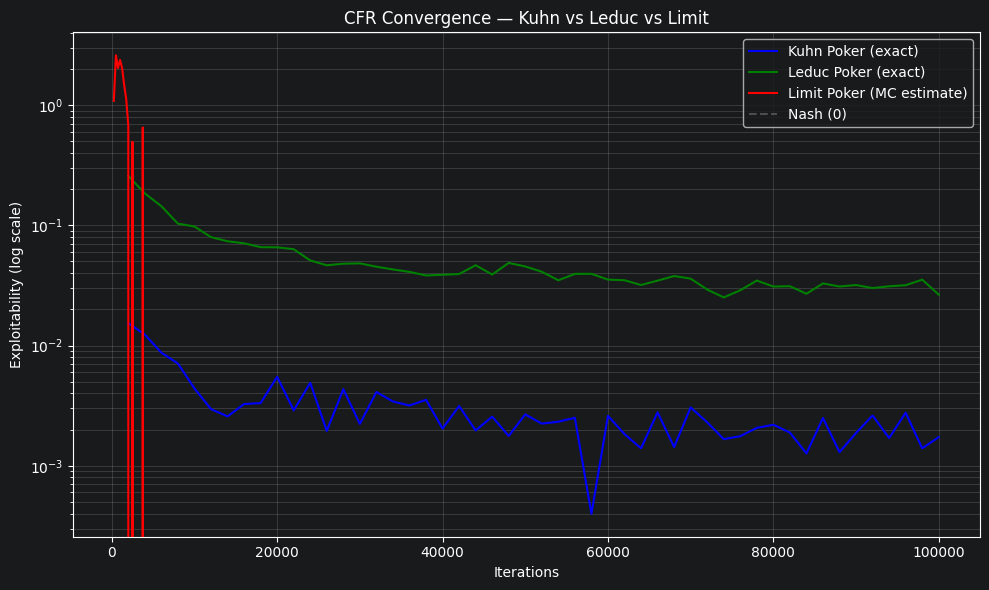

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(kuhn_iters, kuhn_expl, 'b-', linewidth=1.5, label='Kuhn Poker (exact)')
ax.plot(leduc_iters, leduc_expl, 'g-', linewidth=1.5, label='Leduc Poker (exact)')
ax.plot(limit_iters, limit_expl, 'r-', linewidth=1.5, label='Limit Poker (MC estimate)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Nash (0)')

ax.set_xlabel('Iterations')
ax.set_ylabel('Exploitability (log scale)')
ax.set_title('CFR Convergence — Kuhn vs Leduc vs Limit')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()